# Lab 2: Analysis Notebook — Framingham Heart Study (teaching subset)

**Course:** PUBH 4201
**Dataset:** Framingham Heart Study teaching subset (`framingham.csv`)

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
fram = pd.read_csv(url)

fram.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
fram.info()
print()
print("Missing values per column:")
print(fram.isna().sum().sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB

Missing values per colu

In [3]:
# Bin continuous age into four groups
bins = [0, 44, 54, 64, 120]
labels = ["<45", "45-54", "55-64", "65+"]
fram["age_group"] = pd.cut(fram["age"], bins=bins, labels=labels, right=True)

fram["smoking_status"] = fram["currentSmoker"].map({1: "Current smoker", 0: "Non-smoker"})

# CHD prevalence by age group and smoking status
summary = (
    fram
    .groupby(["age_group", "smoking_status"], observed=True)
    .agg(n=("TenYearCHD", "size"), chd_cases=("TenYearCHD", "sum"))
)
summary["chd_prevalence_pct"] = 100 * summary["chd_cases"] / summary["n"]
summary = summary.reset_index()
summary

,age_group,smoking_status,n,chd_cases,chd_prevalence_pct
0,<45,Current smoker,862,70,8.120650
1,<45,Non-smoker,565,22,3.893805
2,45-54,Current smoker,767,134,17.470665
3,45-54,Non-smoker,729,89,12.208505
4,55-64,Current smoker,419,113,26.968974
5,55-64,Non-smoker,731,154,21.067031
6,65+,Current smoker,47,16,34.042553
7,65+,Non-smoker,120,46,38.333333


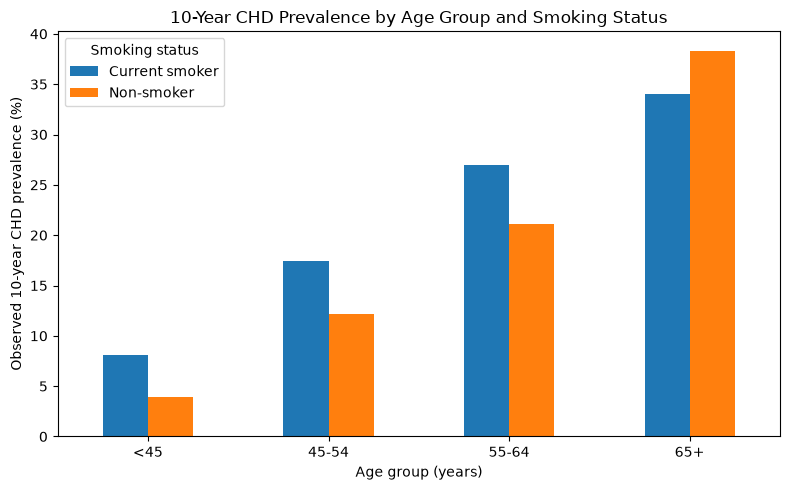

In [4]:
import matplotlib.pyplot as plt

pivot = summary.pivot(index="age_group", columns="smoking_status", values="chd_prevalence_pct")
pivot = pivot.reindex(labels)  # keep age order 

ax = pivot.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Observed 10-year CHD prevalence (%)")
ax.set_title("10-Year CHD Prevalence by Age Group and Smoking Status")
ax.legend(title="Smoking status")
plt.tight_layout()
plt.show()

##Interpretation

The steady incease of CHD prevalence across age groups shows that people become more at risk of CHD as they grow older. For example, CHD prevalnce is the highest in the age group of 65+ among both smoking statuses (current smokers and non-smokers). Current smokers have higher CHD prevalence than non-smokers in every age group except 65+, where non-smokers actually surpass smokers (38% vs 34%). This is probably because many smokers may not make it to the 65+ age group, so this might explain why non-smokers surpass current smokers in that group.